The following file is unused. I don't remember what I was doing here.


EXPERIMENT 1: Uniform Bounded Weights

Heatmap Experiment: Uniform Bounded Weights
Training points: 200, Test points: 743
Weights: min=0.0000, max=1.0000, n_eff=144.0/200
  Sampling for k_s = 0.0...
    k_h = 0.0: PCIC=1.568, Gen=2.377, Bias=-0.809
    k_h = 1.0: PCIC=1.567, Gen=2.404, Bias=-0.837
    k_h = 2.0: PCIC=1.567, Gen=2.407, Bias=-0.840
    k_h = 3.0: PCIC=1.567, Gen=2.408, Bias=-0.840
    k_h = 4.0: PCIC=1.567, Gen=2.407, Bias=-0.840
    k_h = 5.0: PCIC=1.567, Gen=2.406, Bias=-0.839
    k_h = 6.0: PCIC=1.567, Gen=2.404, Bias=-0.837
    k_h = 7.0: PCIC=1.566, Gen=2.400, Bias=-0.834
  Sampling for k_s = 1.0...
    k_h = 0.0: PCIC=1.964, Gen=2.300, Bias=-0.335
    k_h = 1.0: PCIC=1.571, Gen=2.405, Bias=-0.834
    k_h = 2.0: PCIC=1.568, Gen=2.413, Bias=-0.844
    k_h = 3.0: PCIC=1.568, Gen=2.414, Bias=-0.845
    k_h = 4.0: PCIC=1.568, Gen=2.414, Bias=-0.846
    k_h = 5.0: PCIC=1.568, Gen=2.414, Bias=-0.846
    k_h = 6.0: PCIC=1.568, Gen=2.414, Bias=-0.846
    k_h = 7.0: PCIC=1.

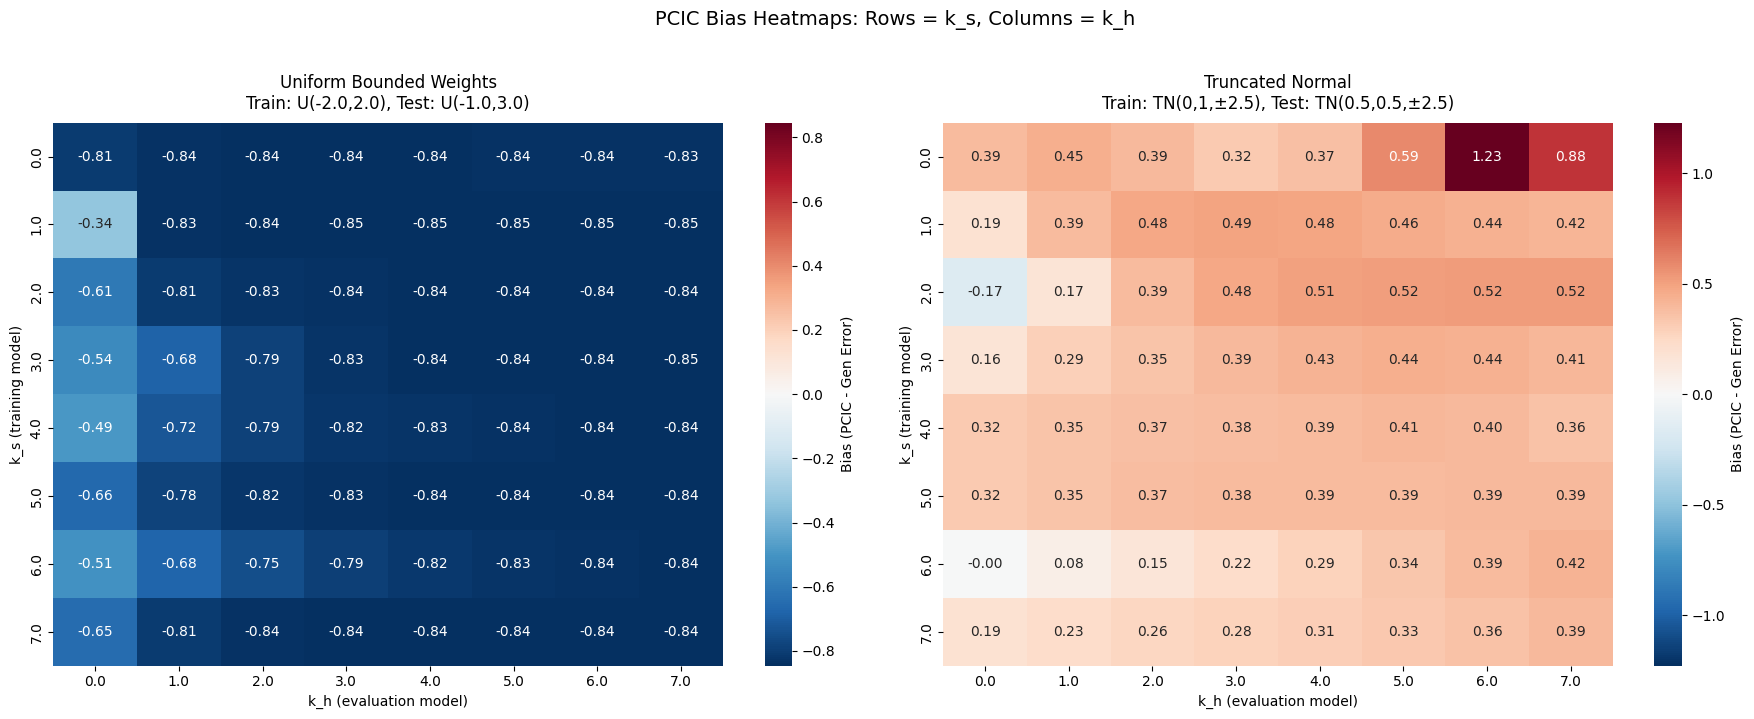

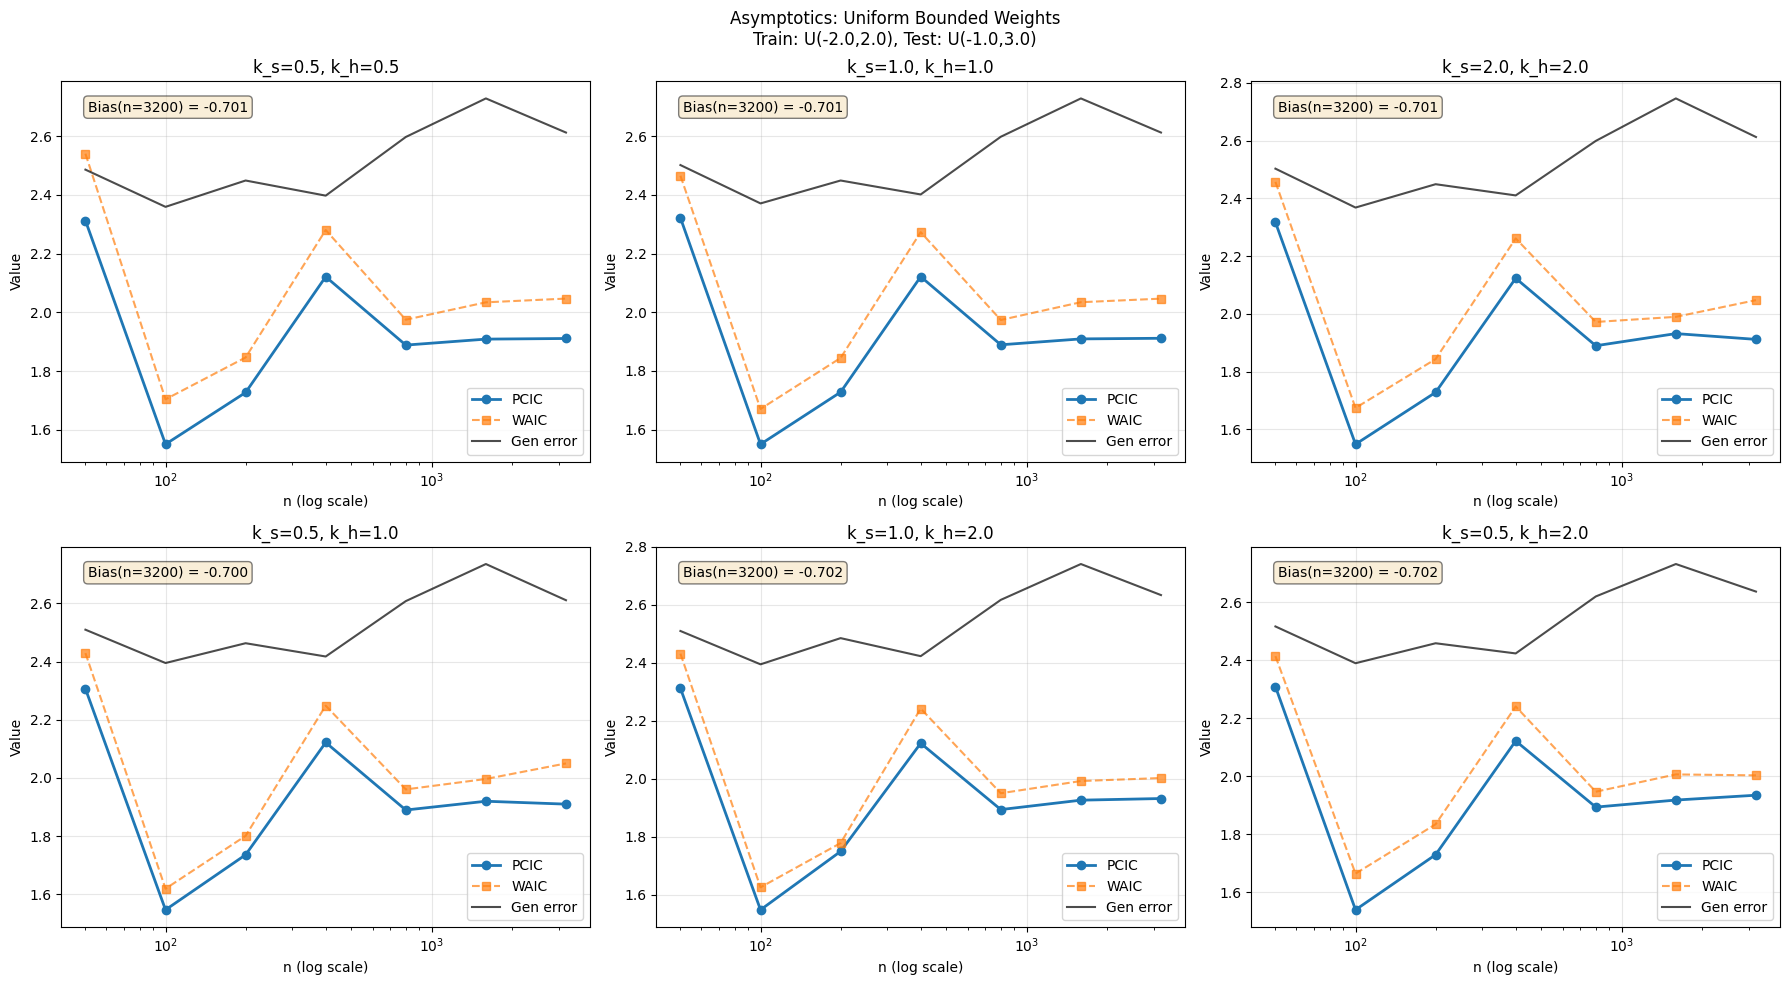

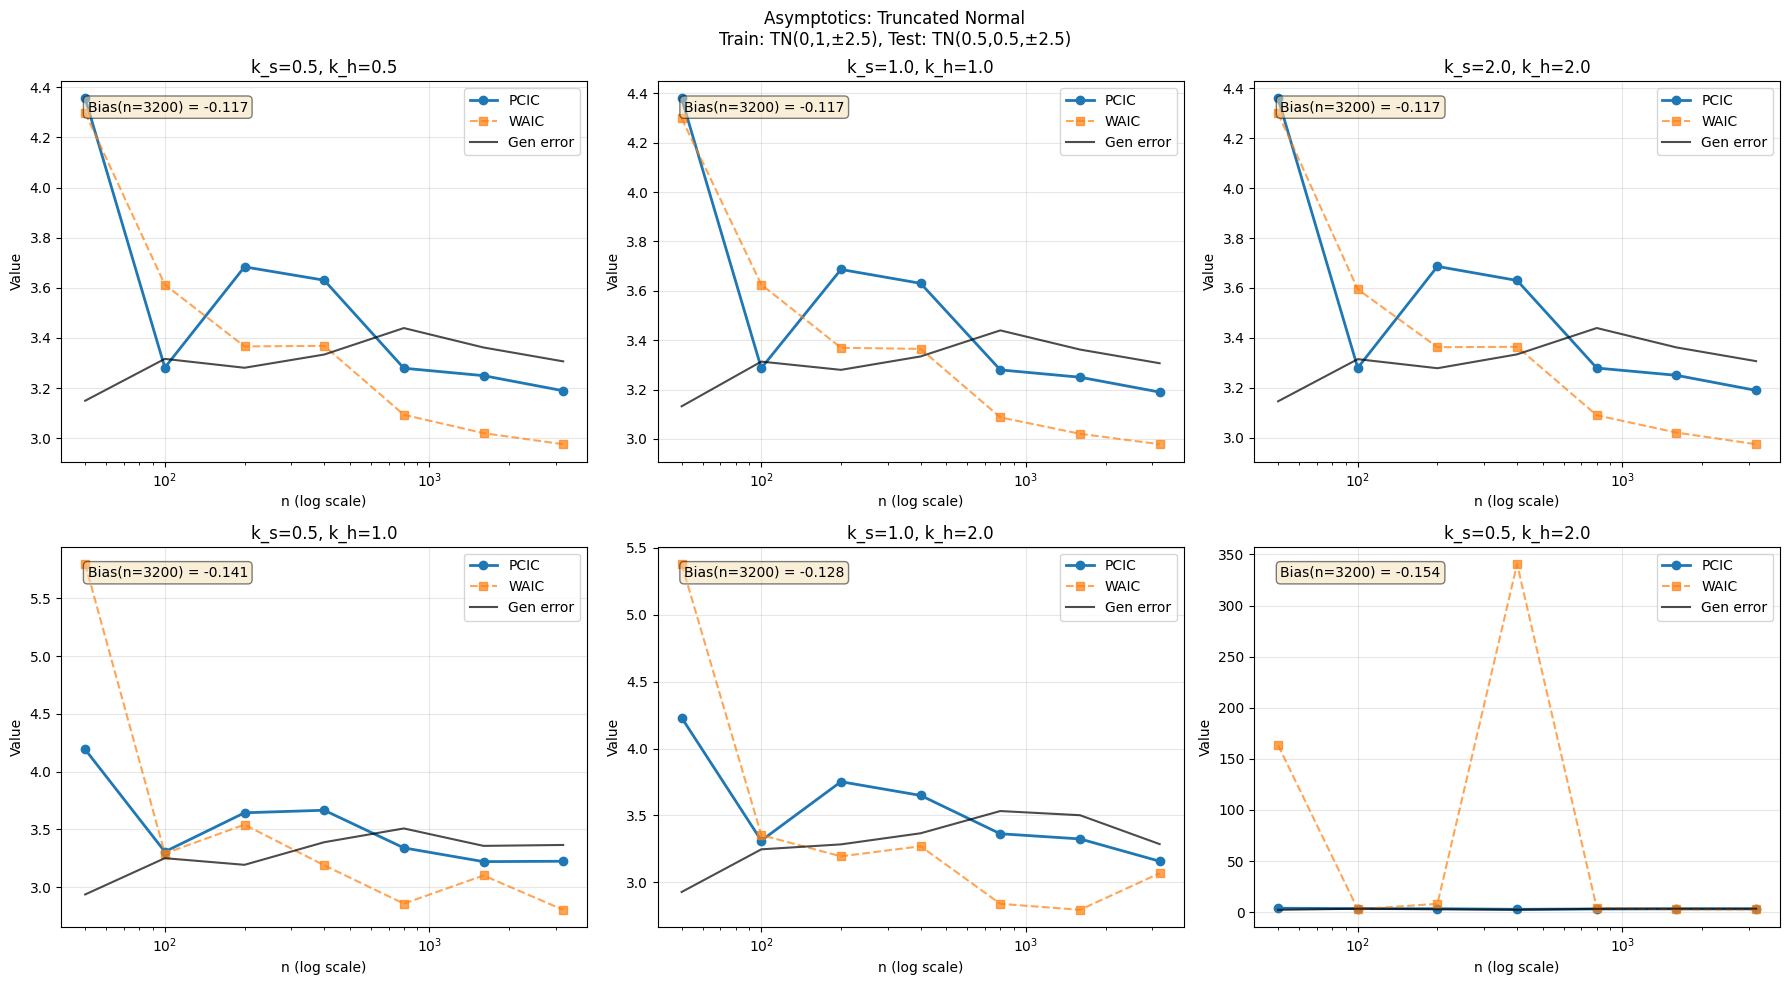

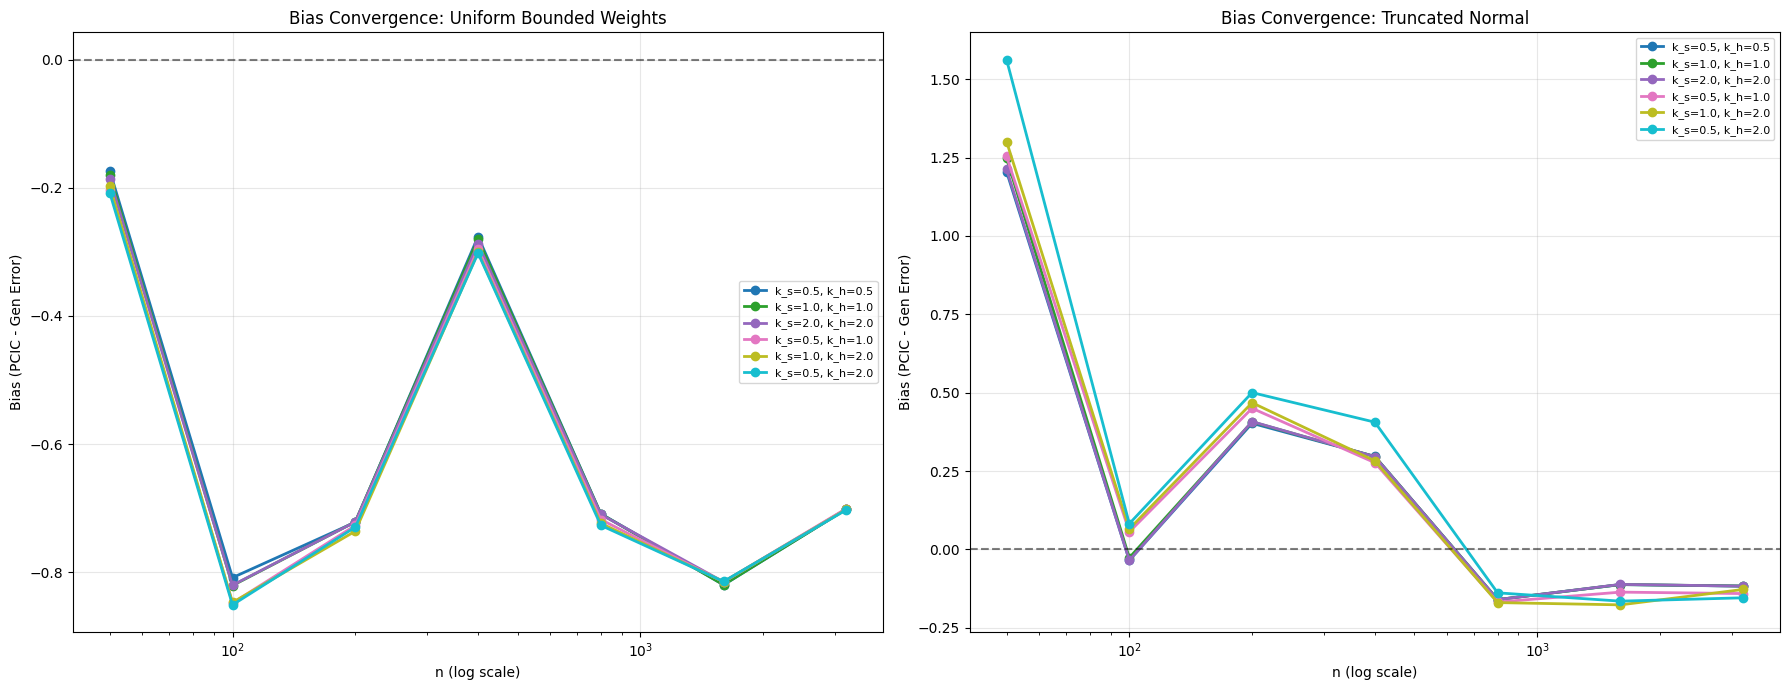


Done!


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, truncnorm
from scipy.special import logsumexp

# ── Constants ────────────────────────────────────────────────────────────────
SIGMA        = 0.25
N_SAMPLES    = 3000
BURN_IN      = 1000
PROPOSAL_STD = 0.05
N_TE         = 1000

# Train/test covariate distributions - using overlapping uniforms for bounded weights
TRAIN_LOW, TRAIN_HIGH = -2.0, 2.0
TEST_LOW,  TEST_HIGH  = -1.0, 3.0

# ── Model ────────────────────────────────────────────────────────────────────
def pred_monomial(theta, x, k):
    """f(x; θ) = |θ₀|^(2k) · θ₁ · x    shape: (S, n)"""
    return (np.abs(theta[:, 0]) ** (2 * k) * theta[:, 1])[:, np.newaxis] * x


def log_lik_matrix(Y, X, theta, k):
    """Log-likelihood for each (sample, observation) pair.   shape: (S, n)"""
    lc = -0.5 * np.log(2 * np.pi * SIGMA ** 2)
    return lc - 0.5 * (Y - pred_monomial(theta, X, k)) ** 2 / SIGMA ** 2


# ── Sampler ──────────────────────────────────────────────────────────────────
def sample_posterior(Y, X, weights, k, use_weights=True):
    """Metropolis-Hastings for the weighted quasi-posterior.
    
    If use_weights=False, uses uniform weights (standard posterior).
    """
    theta = np.array([0.5, 0.5])  # Start away from singularity
    samples = np.zeros((N_SAMPLES, 2))

    def log_post(t):
        pred = np.abs(t[0]) ** (2 * k) * t[1] * X
        ll   = -0.5 * np.log(2 * np.pi * SIGMA ** 2) - 0.5 * (Y - pred) ** 2 / SIGMA ** 2
        if use_weights:
            return np.sum(weights * ll) + np.sum(norm.logpdf(t, 0, 1))
        else:
            return np.sum(ll) + np.sum(norm.logpdf(t, 0, 1))

    curr_lp = log_post(theta)
    accepted = 0
    for i in range(N_SAMPLES + BURN_IN):
        prop    = theta + np.random.normal(0, PROPOSAL_STD, 2)
        prop_lp = log_post(prop)
        if np.log(np.random.rand()) < prop_lp - curr_lp:
            theta, curr_lp = prop, prop_lp
            if i >= BURN_IN:
                accepted += 1
        if i >= BURN_IN:
            samples[i - BURN_IN] = theta
    
    acc_rate = accepted / N_SAMPLES
    return samples, acc_rate


# ── Metrics ──────────────────────────────────────────────────────────────────
def compute_metrics(Y_tr, X_tr, weights, Y_te, X_te, samples, k_s, k_h):
    """
    Returns (PCIC, WAIC, gen_err, diagnostics_dict).

    PCIC formula (eq. 1 in paper):
        -Σ (w_i/n) log E_pos[h_i]  +  Σ (w_i/n) Cov_pos[log h_i, s_i]

    The quasi-posterior uses score  s_i = w_i · log h_i^{k_s}  (see sampler).
    """
    S = len(samples)
    n = len(Y_tr)

    ll_h_tr = log_lik_matrix(Y_tr, X_tr, samples, k_h)   # (S, n)
    ll_s_tr = log_lik_matrix(Y_tr, X_tr, samples, k_s)   # (S, n)
    ll_h_te = log_lik_matrix(Y_te, X_te, samples, k_h)   # (S, n_te)

    # First term: -Σ (w_i/n) log E_pos[h_i(Y_i|θ)]
    lse_h = logsumexp(ll_h_tr, axis=0) - np.log(S)       # log E_pos[h_i],  shape (n,)
    term1 = -np.dot(weights, lse_h) / n

    # Penalty: Σ (w_i²/n) Cov_pos[log h_i^{k_h}, log h_i^{k_s}]
    mean_h      = ll_h_tr.mean(axis=0)
    mean_s      = ll_s_tr.mean(axis=0)
    cov_per_obs = ((ll_h_tr - mean_h) * (ll_s_tr - mean_s)).mean(axis=0)  # (n,)
    term2       = np.dot(weights ** 2, cov_per_obs) / n

    # WAIC (unweighted baseline, same k_h model)
    waic = (np.var(ll_h_tr, axis=0) - lse_h).sum() / n

    # Generalisation error on held-out test data
    gen_err = -np.mean(logsumexp(ll_h_te, axis=0) - np.log(S))

    # Diagnostics
    n_eff = (np.sum(weights) ** 2) / np.sum(weights ** 2) if np.sum(weights) > 0 else 0
    diag = {
        'n_eff': n_eff,
        'w_min': weights.min(),
        'w_max': weights.max(),
        'w_mean': weights.mean(),
        'w_std': weights.std(),
        'term1': term1,
        'term2': term2,
        'penalty_fraction': term2 / (abs(term1) + abs(term2)) if abs(term1)+abs(term2) > 0 else 0
    }

    return term1 + term2, waic, gen_err, diag


# ── Data Generators ──────────────────────────────────────────────────────────
def get_data_uniform_bounded(n_tr, n_te=N_TE):
    """Uniform distributions with bounded, computable density ratio."""
    X_tr = np.random.uniform(TRAIN_LOW, TRAIN_HIGH, n_tr)
    X_te = np.random.uniform(TEST_LOW, TEST_HIGH, n_te)
    
    Y_tr = np.sinc(X_tr) + np.random.normal(0, SIGMA, n_tr)
    Y_te = np.sinc(X_te) + np.random.normal(0, SIGMA, n_te)
    
    p_train = 1.0 / (TRAIN_HIGH - TRAIN_LOW)
    p_test = 1.0 / (TEST_HIGH - TEST_LOW)
    
    weights = np.ones(n_tr) * (p_test / p_train)
    weights[(X_tr < TEST_LOW) | (X_tr > TEST_HIGH)] = 0
    
    mask = (X_te >= TRAIN_LOW) & (X_te <= TRAIN_HIGH)
    X_te = X_te[mask]
    Y_te = Y_te[mask]
    
    return X_tr, Y_tr, X_te, Y_te, weights


def get_data_truncated_normal(n_tr, n_te=N_TE, mu_train=0.0, sd_train=1.0, 
                              mu_test=0.5, sd_test=0.5, trunc=3.0):
    """Truncated normal distributions to ensure bounded density ratio."""
    a_train, b_train = (-trunc - mu_train) / sd_train, (trunc - mu_train) / sd_train
    a_test, b_test = (-trunc - mu_test) / sd_test, (trunc - mu_test) / sd_test
    
    X_tr = truncnorm.rvs(a_train, b_train, loc=mu_train, scale=sd_train, size=n_tr)
    X_te = truncnorm.rvs(a_test, b_test, loc=mu_test, scale=sd_test, size=n_te)
    
    Y_tr = np.sinc(X_tr) + np.random.normal(0, SIGMA, n_tr)
    Y_te = np.sinc(X_te) + np.random.normal(0, SIGMA, n_te)
    
    weights = (truncnorm.pdf(X_tr, a_test, b_test, loc=mu_test, scale=sd_test) / 
               truncnorm.pdf(X_tr, a_train, b_train, loc=mu_train, scale=sd_train))
    
    return X_tr, Y_tr, X_te, Y_te, weights


# ── Heatmap Experiment ───────────────────────────────────────────────────────
def run_heatmap_experiment(data_generator, name, k_values, n_train=200, seed=42):
    """Generate a heatmap of PCIC bias for different (k_s, k_h) pairs."""
    np.random.seed(seed)
    
    n_k = len(k_values)
    bias_mat = np.zeros((n_k, n_k))
    
    print(f"\n{'='*60}")
    print(f"Heatmap Experiment: {name}")
    print(f"{'='*60}")
    
    # Get one dataset for all k pairs
    X_tr, Y_tr, X_te, Y_te, weights = data_generator(n_train)
    
    n_eff = (np.sum(weights) ** 2) / np.sum(weights ** 2) if np.sum(weights) > 0 else 0
    print(f"Training points: {len(X_tr)}, Test points: {len(X_te)}")
    print(f"Weights: min={weights.min():.4f}, max={weights.max():.4f}, "
          f"n_eff={n_eff:.1f}/{n_train}")
    
    # For each k_s, sample posterior once and evaluate all k_h
    for i, ks in enumerate(k_values):
        print(f"  Sampling for k_s = {ks:.1f}...")
        samples, acc_rate = sample_posterior(Y_tr, X_tr, weights, ks)
        
        for j, kh in enumerate(k_values):
            pcic, _, gen, diag = compute_metrics(
                Y_tr, X_tr, weights, Y_te, X_te, samples, ks, kh
            )
            bias_mat[i, j] = pcic - gen
            print(f"    k_h = {kh:.1f}: PCIC={pcic:.3f}, Gen={gen:.3f}, "
                  f"Bias={bias_mat[i,j]:.3f}")
    
    return bias_mat, k_values


def run_asymptotic_experiment(data_generator, name, k_pairs, seed=42):
    """Run asymptotic bias experiment."""
    np.random.seed(seed)
    
    n_vals = [50, 100, 200, 400, 800, 1600, 3200]
    
    results = {pair: {'pcic': [], 'waic': [], 'gen': [], 'diag': []} 
               for pair in k_pairs}
    
    print(f"\n{'='*60}")
    print(f"Asymptotic Experiment: {name}")
    print(f"{'='*60}")
    
    for n in n_vals:
        print(f"\nn = {n}")
        X_tr, Y_tr, X_te, Y_te, weights = data_generator(n)
        
        if np.sum(weights) > 0:
            n_eff = (np.sum(weights) ** 2) / np.sum(weights ** 2)
        else:
            n_eff = 0
        print(f"  Training points: {len(X_tr)}, Test points: {len(X_te)}")
        print(f"  Weights: min={weights.min():.4f}, max={weights.max():.4f}, "
              f"n_eff={n_eff:.1f}/{n}")
        
        for ks, kh in k_pairs:
            samples, acc_rate = sample_posterior(Y_tr, X_tr, weights, ks)
            pcic, waic, gen, diag = compute_metrics(
                Y_tr, X_tr, weights, Y_te, X_te, samples, ks, kh
            )
            
            results[(ks, kh)]['pcic'].append(pcic)
            results[(ks, kh)]['waic'].append(waic)
            results[(ks, kh)]['gen'].append(gen)
            results[(ks, kh)]['diag'].append(diag)
            
            bias = pcic - gen
            print(f"  k_s={ks:.1f}, k_h={kh:.1f}: PCIC={pcic:.3f}, "
                  f"Gen={gen:.3f}, Bias={bias:.3f}, "
                  f"AccRate={acc_rate:.2f}")
    
    return n_vals, results


# ── Plotting ──────────────────────────────────────────────────────────────────
def plot_heatmap(bias_mat, k_values, title, ax=None):
    """Plot a single heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Format k_values as strings for tick labels
    k_labels = [f"{k:.1f}" for k in k_values]
    
    vmax = max(abs(bias_mat.min()), abs(bias_mat.max()))
    
    sns.heatmap(bias_mat, annot=True, fmt=".2f",
                xticklabels=k_labels, yticklabels=k_labels,
                cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                ax=ax, cbar_kws={'label': 'Bias (PCIC - Gen Error)'})
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("k_h (evaluation model)")
    ax.set_ylabel("k_s (training model)")
    
    return ax


def plot_asymptotic_results(n_vals, results_dict, k_pairs, title_prefix):
    """Plot asymptotic results for given k_pairs."""
    n_pairs = len(k_pairs)
    cols = min(3, n_pairs)
    rows = (n_pairs + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, (ks, kh) in enumerate(k_pairs):
        ax = axes[i]
        res = results_dict[(ks, kh)]
        
        ax.plot(n_vals, res['pcic'], 'o-', label='PCIC', linewidth=2)
        ax.plot(n_vals, res['waic'], 's--', label='WAIC', alpha=0.7)
        ax.plot(n_vals, res['gen'], 'k-', label='Gen error', alpha=0.7)
        ax.set_xscale('log')
        ax.set_xlabel('n (log scale)')
        ax.set_ylabel('Value')
        ax.set_title(f'k_s={ks}, k_h={kh}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        final_bias = res['pcic'][-1] - res['gen'][-1]
        ax.text(0.05, 0.95, f'Bias(n={n_vals[-1]}) = {final_bias:.3f}',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(title_prefix, fontsize=12)
    plt.tight_layout()
    return fig


def plot_bias_comparison(n_vals, results_dict, k_pairs, title):
    """Plot bias (PCIC - Gen error) for all pairs."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(k_pairs)))
    
    for i, (ks, kh) in enumerate(k_pairs):
        res = results_dict[(ks, kh)]
        biases = np.array(res['pcic']) - np.array(res['gen'])
        ax.plot(n_vals, biases, 'o-', color=colors[i], 
                label=f'k_s={ks}, k_h={kh}', linewidth=2)
    
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('n (log scale)')
    ax.set_ylabel('Bias (PCIC - Gen Error)')
    ax.set_title(f'Bias Convergence: {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


# ── Main Execution ───────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Define k values for heatmap (dense grid)
    k_values_heatmap = np.arange(0, 8)
    
    # Define k pairs for asymptotic analysis
    k_pairs_asy = [
        (0.5, 0.5), (1.0, 1.0), (2.0, 2.0),  # Matching pairs
        (0.5, 1.0), (1.0, 2.0), (0.5, 2.0),  # Different k_s, k_h
    ]
    
    # =========================================================================
    # EXPERIMENT 1: Uniform Bounded Weights
    # =========================================================================
    print("\n" + "="*80)
    print("EXPERIMENT 1: Uniform Bounded Weights")
    print("="*80)
    
    # 1a: Heatmap
    bias_mat_1, k_vals_1 = run_heatmap_experiment(
        get_data_uniform_bounded,
        "Uniform Bounded Weights",
        k_values_heatmap,
        n_train=200,
        seed=42
    )
    
    # 1b: Asymptotics
    n_vals_1, results_1 = run_asymptotic_experiment(
        get_data_uniform_bounded,
        "Uniform Bounded Weights",
        k_pairs_asy,
        seed=42
    )
    
    # =========================================================================
    # EXPERIMENT 2: Truncated Normal
    # =========================================================================
    print("\n" + "="*80)
    print("EXPERIMENT 2: Truncated Normal")
    print("="*80)
    
    # 2a: Heatmap
    bias_mat_2, k_vals_2 = run_heatmap_experiment(
        lambda n: get_data_truncated_normal(n, mu_train=0.0, sd_train=1.0,
                                           mu_test=0.5, sd_test=0.5, trunc=2.5),
        "Truncated Normal",
        k_values_heatmap,
        n_train=200,
        seed=123
    )
    
    # 2b: Asymptotics
    n_vals_2, results_2 = run_asymptotic_experiment(
        lambda n: get_data_truncated_normal(n, mu_train=0.0, sd_train=1.0,
                                           mu_test=0.5, sd_test=0.5, trunc=2.5),
        "Truncated Normal",
        k_pairs_asy,
        seed=123
    )
    
    # =========================================================================
    # PLOTTING
    # =========================================================================
    
    # --- Figure 1: Heatmaps side by side ---
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    plot_heatmap(bias_mat_1, k_vals_1, 
                 f"Uniform Bounded Weights\nTrain: U({TRAIN_LOW},{TRAIN_HIGH}), "
                 f"Test: U({TEST_LOW},{TEST_HIGH})",
                 ax=ax1)
    
    plot_heatmap(bias_mat_2, k_vals_2,
                 "Truncated Normal\nTrain: TN(0,1,±2.5), Test: TN(0.5,0.5,±2.5)",
                 ax=ax2)
    
    plt.suptitle("PCIC Bias Heatmaps: Rows = k_s, Columns = k_h", 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('pcic_heatmaps.png', dpi=150, bbox_inches='tight')
    
    # --- Figure 2: Asymptotic plots for Uniform ---
    fig2 = plot_asymptotic_results(
        n_vals_1, results_1, k_pairs_asy,
        f"Asymptotics: Uniform Bounded Weights\n"
        f"Train: U({TRAIN_LOW},{TRAIN_HIGH}), Test: U({TEST_LOW},{TEST_HIGH})"
    )
    fig2.savefig('pcic_asymptotic_uniform.png', dpi=150, bbox_inches='tight')
    
    # --- Figure 3: Asymptotic plots for Truncated Normal ---
    fig3 = plot_asymptotic_results(
        n_vals_2, results_2, k_pairs_asy,
        "Asymptotics: Truncated Normal\n"
        "Train: TN(0,1,±2.5), Test: TN(0.5,0.5,±2.5)"
    )
    fig3.savefig('pcic_asymptotic_truncnormal.png', dpi=150, bbox_inches='tight')
    
    # --- Figure 4: Bias comparison plots ---
    fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Uniform bias convergence
    colors = plt.cm.tab10(np.linspace(0, 1, len(k_pairs_asy)))
    for i, (ks, kh) in enumerate(k_pairs_asy):
        res = results_1[(ks, kh)]
        biases = np.array(res['pcic']) - np.array(res['gen'])
        ax4a.plot(n_vals_1, biases, 'o-', color=colors[i], 
                 label=f'k_s={ks}, k_h={kh}', linewidth=2)
    ax4a.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax4a.set_xscale('log')
    ax4a.set_xlabel('n (log scale)')
    ax4a.set_ylabel('Bias (PCIC - Gen Error)')
    ax4a.set_title('Bias Convergence: Uniform Bounded Weights')
    ax4a.legend(fontsize=8)
    ax4a.grid(True, alpha=0.3)
    
    # Truncated normal bias convergence
    for i, (ks, kh) in enumerate(k_pairs_asy):
        res = results_2[(ks, kh)]
        biases = np.array(res['pcic']) - np.array(res['gen'])
        ax4b.plot(n_vals_2, biases, 'o-', color=colors[i], 
                 label=f'k_s={ks}, k_h={kh}', linewidth=2)
    ax4b.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax4b.set_xscale('log')
    ax4b.set_xlabel('n (log scale)')
    ax4b.set_ylabel('Bias (PCIC - Gen Error)')
    ax4b.set_title('Bias Convergence: Truncated Normal')
    ax4b.legend(fontsize=8)
    ax4b.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pcic_bias_convergence.png', dpi=150, bbox_inches='tight')
    
    # =========================================================================
    # PRINT SUMMARY
    # =========================================================================
    print("\n" + "="*80)
    print("FINAL SUMMARY: Bias (PCIC - Gen Error) at max n")
    print("="*80)
    
    for name, n_vals, results in [
        ("Uniform Bounded", n_vals_1, results_1),
        ("Truncated Normal", n_vals_2, results_2)
    ]:
        print(f"\n{name}:")
        print(f"{'k_s':>6} {'k_h':>6} {'Bias':>10} {'PCIC':>10} {'Gen':>10} "
              f"{'n_eff_frac':>12}")
        print("-" * 58)
        for ks, kh in k_pairs_asy:
            res = results[(ks, kh)]
            bias = res['pcic'][-1] - res['gen'][-1]
            n_eff_frac = res['diag'][-1]['n_eff'] / n_vals[-1]
            print(f"{ks:6.1f} {kh:6.1f} {bias:10.4f} {res['pcic'][-1]:10.4f} "
                  f"{res['gen'][-1]:10.4f} {n_eff_frac:12.3f}")
    
    # Print heatmap summary
    print("\n" + "="*80)
    print("HEATMAP SUMMARY: Bias at k_s = k_h (diagonal)")
    print("="*80)
    print(f"{'k':>6} {'Uniform':>12} {'TruncNorm':>12}")
    print("-" * 35)
    for i, k in enumerate(k_vals_1):
        print(f"{k:6.1f} {bias_mat_1[i,i]:12.4f} {bias_mat_2[i,i]:12.4f}")
    
    plt.show()
    print("\nDone!")